# Work Environment

```{contents}
:local:
:depth: 2
```

## Editing Tools

For most programming languages, including Python, there are many tools you can use to write and run programs. Some of the code-editing development tools are full-featured integrated development environments (IDEs), some are lightweight code editors, while others are specialized development environment such as Jupyter and Google Colab.

- Full IDEs like **PyCharm**, IntelliJ, and Visual Studio are comprehensive environments designed for full-scale software development: building complete applications, managing large codebases, and collaborative development. They're the standard choice for professional software engineering where you need structure, performance, and the ability to handle complex projects. Full IDEs have comprehensive tooling: debuggers, refactoring, testing frameworks, and project management. They're heavier but more powerful for large projects. [PyCharm ](https://www.jetbrains.com/pycharm/) is a popular IDE for both learners and professionals, [VS Code](https://code.visualstudio.com/) is a code editor turned full IDE through extensions. 
 
- Code editors like Visual Studio Code (**VS Code**), Sublime Text, and Notepad++ are lightweight tools for writing and editing code with features like syntax highlighting and basic autocomplete. They're fast to start up, use minimal resources, and have simpler interfaces. Over time, some editors (e.g., VS Code) have evolved and can function as full IDEs. VS Code has even become the industry standard for general software development. According to the [2025 Stack Overflow Developer Survey](https://survey.stackoverflow.co/2025/), approximately 76% of professional developers and 78% of people learning to code use VS Code, making it the most used and most desired editor for several years running. 
  
- Terminal-based editors like **nano** and **vim** in Unix-like (Unix/Linux/macOS) systems run directly in the command line with no graphical interface. Nano is beginner-friendly; vim has a steeper learning curve but is highly efficient once mastered. Both are available on virtually every Unix-like system and are useful when working over SSH or in environments without a GUI. In Windows, **Notepad** is a built-in plain-text editor that is minimal but sufficient for edits.



| Feature | Code Editor | Full IDE |
|---------|----------------------|--------------------------------------|
| Startup Speed | Fast; lightweight | Slower; heavy resource usage |
| Language Support | General-purpose; supports features via plugins/extensions | Specialized; deep, native support for specific languages (e.g., C#, Java) |
| Setup | Requires manual setup/extensions for tasks | Ready for complex projects immediately after installation |
| Cost | Usually free | Often requires paid license for professional version |
| Examples | <img src="https://cdn.jsdelivr.net/gh/devicons/devicon/icons/vscode/vscode-original.svg" height="16"> <a href="https://code.visualstudio.com/" style="text-decoration:none">VS Code</a>, <img src="https://cdn.simpleicons.org/sublimetext" height="16"> <a href="https://www.sublimetext.com/" style="text-decoration:none">Sublime Text</a>, <img src="https://cdn.simpleicons.org/vim" height="16"> <a href="https://www.vim.org/" style="text-decoration:none">Vim</a>, <a href="https://www.nano-editor.org/" style="text-decoration:none">nano</a>, <img src="https://cdn.simpleicons.org/notepadplusplus" height="16"> <a href="https://notepad-plus-plus.org/" style="text-decoration:none">Notepad++</a> | <img src="https://cdn.simpleicons.org/pycharm" height="16"> <a href="https://www.jetbrains.com/pycharm/" style="text-decoration:none">PyCharm</a>, <img src="https://cdn.simpleicons.org/intellijidea" height="16"> <a href="https://www.jetbrains.com/idea/" style="text-decoration:none">IntelliJ</a>, <img src="https://cdn.jsdelivr.net/gh/devicons/devicon/icons/visualstudio/visualstudio-plain.svg" height="16"> <a href="https://visualstudio.microsoft.com/" style="text-decoration:none">Visual Studio</a> |


- **Jupyter Notebook** is a specialized development tool. It's an interactive, cell-based environment primarily designed for data analysis, scientific computing, and exploration. You write code in individual cells that you can execute independently, and results (including visualizations and formatted text) appear immediately inline below the cell. Jupyter supports mixing code, markdown documentation, equations, and outputs in a single document, making it excellent for data science.

As you progress in learning how to code, you may find VS Code and PyCharm more useful when you mainly work on coding rather than data flow and documentation. If you are just getting started, it is recommended that  you start with Jupyter Notebook.

## The File System

Unix-like operating systems are file-based, meaning the design principle dictates that everything in the system is a file, and the files are organized as a tree-like file system structure following the [Filesystem Hierarchy Standard](https://en.wikipedia.org/wiki/Filesystem_Hierarchy_Standard). In the CLI (command line interface) terminal, a file **path** is then used to access a file or a directory/folder in the computer’s hierarchical file structure in the absence of a GUI. Windows systems also have a similar directory structure.

The file system's tree-like directory structure begins with the **root** (represented by the `/` symbol and `C:\\` in Windows systems) directory, which contains several default first-level directories representing various functionalities as shown in {numref}`linux_directory_tree`. For example, the `bin` (binary) directory is the standard location contains compiled executable programs (i.e., "binaries"), and the `dev` (device) directory contains device files allowing software to communicate with hardware.

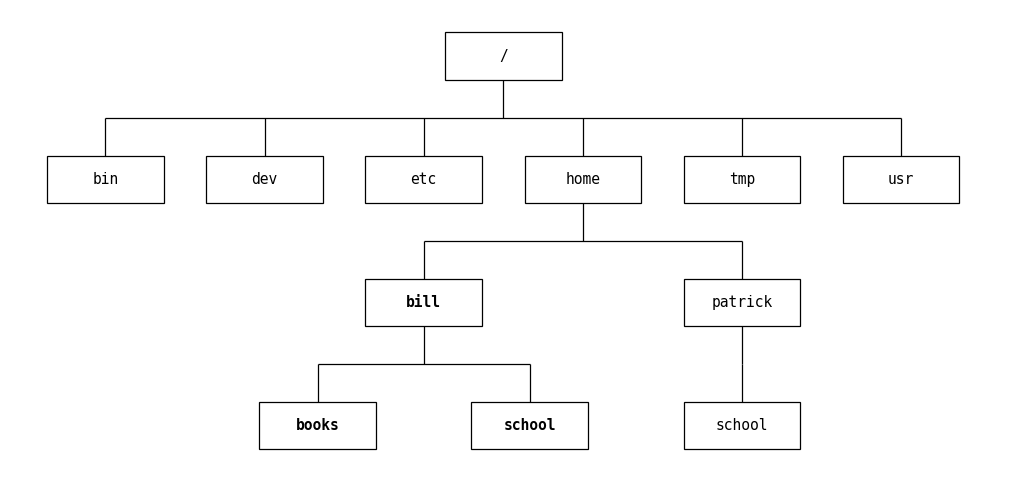

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.set_xlim(-0.4, 9.0)
ax.set_ylim(-0.1, 4.55)
ax.axis('off')

W, H   = 1.1, 0.46          # box width, height
lw     = 0.9
color  = 'black'
FONT   = 'monospace'
FS     = 10.5

Y = [4.1, 2.9, 1.7, 0.5]    # row centre y-coords, top → bottom

nodes = {                     # id: (cx, cy, label, bold)
    'root':    (4.25, Y[0], '/',       False),
    'bin':     (0.5,  Y[1], 'bin',     False),
    'dev':     (2.0,  Y[1], 'dev',     False),
    'etc':     (3.5,  Y[1], 'etc',     False),
    'home':    (5.0,  Y[1], 'home',    False),
    'tmp':     (6.5,  Y[1], 'tmp',     False),
    'usr':     (8.0,  Y[1], 'usr',     False),
    'bill':    (3.5,  Y[2], 'bill',    True),
    'patrick': (6.5,  Y[2], 'patrick', False),
    'books':   (2.5,  Y[3], 'books',   True),
    'school1': (4.5,  Y[3], 'school',  True),
    'school2': (6.5,  Y[3], 'school',  False),
}

tree = {                      # parent → ordered children
    'root':    ['bin', 'dev', 'etc', 'home', 'tmp', 'usr'],
    'home':    ['bill', 'patrick'],
    'bill':    ['books', 'school1'],
    'patrick': ['school2'],
}

BUS_Y = {k: (nodes[k][1] + nodes[v[0]][1]) / 2 for k, v in tree.items()}

kw = dict(color=color, lw=lw, solid_capstyle='butt', zorder=1)

# ── edges ──
for parent, children in tree.items():
    px, py, *_ = nodes[parent]
    bus_y = BUS_Y[parent]
    xs = [nodes[c][0] for c in children]

    ax.plot([px, px], [py - H/2, bus_y], **kw)
    ax.plot([min(xs), max(xs)], [bus_y, bus_y], **kw)
    if not (min(xs) <= px <= max(xs)):
        ax.plot([px, min(xs) if px < min(xs) else max(xs)], [bus_y, bus_y], **kw)

    for c in children:
        cx, cy, *_ = nodes[c]
        ax.plot([cx, cx], [bus_y, cy + H/2], **kw)

# ── nodes ──
for nid, (cx, cy, label, bold) in nodes.items():
    ax.add_patch(patches.Rectangle(
        (cx - W/2, cy - H/2), W, H,
        linewidth=0.9, edgecolor=color, facecolor='white', zorder=3))
    ax.text(cx, cy, label, ha='center', va='center',
            fontfamily=FONT, fontweight='bold' if bold else 'normal',
            fontsize=FS, zorder=4)

plt.tight_layout(pad=0.1)
fig.savefig('../../figures/linux_directory_tree.png', dpi=150, bbox_inches='tight')
plt.show()

Another first-level directories requires your attention is the `home` (`Users` in Windows and macOS) directory, which contains the users' individual user home directories, specified as `/home/[username]` (`C:\Users\` in Windows). Note that when you log into the system in terminal, this `/home/[username]` user home directory is usually your default working directory where the user types commands in the command prompt to interact with the system.

In the example above, *bill* and *patrick* are two users and their user home directories are `/home/bill/` and `/home/patrick/` respectively. When a user, for example, *bill* logs into the system, he will be in the `bill` user home directory and if he types a command `ls` and hit Enter, he will see that he has two folders in his user home directory: `books` and `school`.  



````{tab-set}
```{tab-item} Windows
```powershell
PS C:\Users\[user]> ls

    Directory: C:\Users\tychen

Mode                 LastWriteTime         Length Name
----                 -------------         ------ ----
...
d-----          6/5/2026  12:40 AM                books
d-----          6/5/2026   2:31 AM                school

```

```{tab-item} macOS
```bash
[user]@[computer]:~$ ls
books school

[user]@[computer]:~$ ls
```
````



Similarly, in Windows, files and directories are organized in a hierarchical structure; except that drive letters such as `C:` and `D:` are used for separate file structure roots, while Linux uses a unified, hierarchical structure starting from a single **root** (`/`) for all drives and devices. In {numref}`windows11-directory-c-drive`, you see that, in File Explorer, if you click on Local Disk `C:` under `This PC`, there is a number of folders and files organized under the `C:` drive, you see a number of first-level directories just like under the root in Linux.

```{figure} ../../figures/windows11-directory-c-drive.png
:name: windows11-directory-c-drive
:alt: windows11-directory-c-drive
:width: 75%
:align: center

Windows 11 Directory C: Drive
```

If you click to expand the `Users` folder, File Explorer will display the folders (usernames) contained within it. When you select to highlight a username, you will see all the files and directories of that user. In this example in {numref}`windows11-directory-user`, a folder called **`workspace`** is highlighted. 

Note that, in the CLI, this user home (`C:\User\[username]`) folder is the default location when a user logs in, just like in the Unix-like systems. 

```{figure} ../../figures/windows11-directory-user.png
:name: windows11-directory-user
:alt: windows11-directory-user
:width: 75%
:align: center

Windows 11 Directory Hierarchy from C: Drive to User Home Directory
```

## Command Line Basics

Having some knowledge of using the CLI is necessary when learning how to code. A CLI is often referred to, interchangeably, as the _command prompt_ in Windows, **shell** in Linux/macOS, or **command line** or **terminal** in general. Major operating systems all have CLIs for users to interact with the operating system by issuing text commands in the CLI rather than using GUIs to gain speed, automation, and granular control. (For a discussion on terminology such as terminal, console, and shell, see [here](https://www.hanselman.com/blog/whats-the-difference-between-a-console-a-terminal-and-a-shell)).


A CLI environment usually include: 
| Term | Definition | Examples |
|---|---|---|
| **Terminal** | An application program (also called a "terminal emulator," since it emulates the locally-attached dumb terminals of early computing) that starts a CLI window with a default shell environment. | `Terminal.app` (macOS), `Windows PowerShell`, `GNOME Terminal` |
| **Shell** | A command-line interface to the computer and a computer language interpreter interpreting the user's commands to the operating system. | `bash`, `zsh`, `PowerShell` |
| **REPL** | A Read–Eval–Print Loop — an interactive programming environment for a specific language. | Python's `>>>` prompt, `csharprepl` for C# |

In summary, terminals are programs like Windows PowerShell/Command Prompt, macOS Terminal.app, or Linux Terminal that you open to access the `shell`. A `shell` is a command-line **interpreter** that interprets the commands you enter to work with the operating system. Note that a GUI is also considered a shell as it interfaces with the OS.

When you open the CLI terminal application, you mainly use the keyboard, rather than a mouse, to issue text commands (you can still mostly use the mouse to highlight and copy/paste text). 

To start using the CLI, you start a **terminal session** first.

````{tab-set}
```{tab-item} Windows
In Windows, you search for *PowerShell*, and you will see **Windows PowerShell** as an app. Click on it and you will see PowerShell window opening. You should see the shell in blue color with a blinking vertical bar at the command prompt line. That's where you type your commands.

```poweshell
Windows PowerShell
Copyright (C) Microsoft Corporation. All rights reserved.

Loading personal and system profiles took 551ms.
PS C:\Users\tychen>
```

```{tab-item} macOS
For macOS/Linux, you search for **Terminal.app**. You then mouse-click on the application or press _Enter_ to open the terminal application and access the shell. If you have not customized your terminal, it may open as a small, plain window, and the default shell may be zsh. The command prompt may have a vertical block and that's where you type your commands.
```bash
Last login: Sat Sep  5 16:48:40 on ttys001

tychen✪mba:~$ 

```
````

### Pathname and Special Characters

Before learning shell commands, it is useful to know the pathname characters that describe locations in the file system. These characters are supported by major shells such as Bash and PowerShell:

- **`/`** is the system root for Unix-like system’s file directory tree structure. It is also used as a separator for building file path.
- **`\`** is the path separator for Windows paths, such as `C:\Users\[user]`, although Windows recognizes both forward slash (`/`) and backward slash (`\`) for path separator. In many programming languages, it can also act as an escape character.
- **`~`** represent the user’s home directory.
- **`..`** is the parent directory, which is relatively one level up from the current directory.
- `.` means the current directory. When placed at the beginning of a filename, it makes the file hidden.
- Quotation marks, such as `"My Folder"`, are used around paths that contain spaces.

When starting the terminal, you should be in the user home directory by default. That is, you should see your username at the command prompt line. If you are not, you can use the change directory (**`cd`**) command to switch directory into your user home directory.

````{tab-set}
```{tab-item} Windows
You should be in your user home directory when logged in and may see your username. 

```powershell
PS C:\Users\[user]>

```
At anytime (including when you just log in), if you are not in your user home directory (e.g., you are in the `C:\Windows\System`), `cd` into your user home directory (`~`): 

```powershell
PS C:\Windows\System> cd ~
PS C:\Users\[user]>

```

You can move up one level in the shell by issuing the command `cd ..`, which means changing directory to the directory one level up. In the case here, you will be moving from your user home directory to the system's `home`/`Users` directory, where you can issue the `ls` command to see the individual user home directories. 

```powershell
PS C:\Users\[user]> cd ..
PS C:\Users>ls

    Directory: C:\Users

Mode                 LastWriteTime         Length Name
----                 -------------         ------ ----
d-r---         8/30/2025   5:52 PM                Public
d----l         8/30/2025   4:23 PM                [user1]
d-----          9/6/2026   8:00 PM                [user2]

PS C:\Users>
```

Or, you can build a path/pathname and change directory to the path location. For example, you may want change into your own Desktop folder, which is `/home/[user]/Desktop` if you start the path from the root (`/`).

```powershell
PS C:\Users\[user]> cd C:\Users\tychen\Desktop\
PS C:\Users\[user]\Desktop>
```

```{tab-item} macOS
You should be in your user home directory when logged in and may see your computer name and username. 

```bash
[user]@[computer]:~$ 

```
At anytime (including when you just log in), if you are not in your user home directory (e.g., you are in `[user]@[computer]:/Users$`, `cd` into your user home directory (`~`): 

```bash
[user]@[computer]:/Users$ cd ~
[user]@[computer]:~$ 

```

You can move up one level in the shell by issuing the command `cd ..`, which means changing directory to the directory one level up. In the case here, you will be moving from your user home directory to the system's `home`/`Users` directory, where you can issue the `ls` command to see the individual user home directories. 

```bash
[user]@[computer]:~$ cd .. 
[user]@[computer]:/Users$ ls
Guest        Shared       [user1] [user2]
[user]@[computer]:/Users$ 
```

Or, you can build a path/pathname and change directory to the path location. For example, you may want change into your own Desktop folder, which is `/home/[user]/Desktop` if you start the path from the root (`/`).

```bash
[user]@[computer]:~$ cd /home/[user]/Desktop
[user]@[computer]:~/Desktop$

````


### Essential Commands

After you know how to describe paths, the essential commands below help you navigate and manage files from the command line.

| Group | Command | Name | What it does |
|---|---|---|---|
| Navigation | `ls` | list | Shows the files and directories in the current directory. |
|  | `cd` *path* | change directory | Moves the shell to another directory in the file tree. |
|  | `pwd` | print working directory | Shows the full path of the current directory. |
| File operations | `mkdir` *foldername* | make directory | Creates a new empty directory. |
|   | `touch` *filename* | — | Creates a new empty file or updates the timestamp of an existing file. |
|   | `cp` *source_file destination* | copy | Copies a file from the source path to the destination path. |
|   | `mv` *source destination* | move | Moves a file or directory. Also used to rename files, e.g. `mv old.txt new.txt`. |
|   | `rm` *filename* | remove | Deletes a file. Use carefully — removed files may not go to the trash. |
| Output | `echo` *text* | — | Prints text to the terminal, e.g. `echo hello` displays `hello`. |
|  | `cat` *filename* | concatenate | Displays the contents of a text file in the terminal. |
| Session control | `clear` | — | Clears the terminal screen so the prompt appears at the top again. |
|   | `^C` / `Ctrl+C` | — | Interrupts or terminates a running command. |
|   | `exit` | — | Exits the current shell session or closes the terminal. |

### Creating Directories and Files

Suppose that you are in your user home directory and you would like to create a directory/folder called `test_dir` in your home diretory, you may use the `mkdir` command for that purpose and then use `ls` to make sure the directory is created.

````{tab-set}
```{tab-item} Windows
```powershell
PS C:\Users\[user]> 
PS C:\Users\[user]> mkdir test_dir

    Directory: C:\Users\[user]

Mode                 LastWriteTime         Length Name
----                 -------------         ------ ----
d-----          9/6/2026  10:34 PM                test_dir

PS C:\Users\[user]> ls
d-----          9/8/2025  11:51 PM                .cache
...
d-----         9/11/2025  12:01 AM                .ssh
...
d-r---         8/30/2025   5:52 PM                Contacts
d-r---         9/11/2025  12:35 AM                Desktop
d-----         9/12/2025  10:27 AM                Documents
d-r---        12/25/2025  10:42 PM                Downloads
...
d-----          9/6/2026  10:34 PM                test_dir
...
PS C:\Users\[user]> 
```

```{tab-item} macOS
For macOS, instead of `ls`, let's use `ls -l` (`-l` option stands for long format).

```bash
[user]@[computer]:~$ mkdir test_dir
[user]@[computer]:~$ ls
total 0
...
drwxr-xr-x   11 [user]  staff    352 Aug 22 06:57 Applications
drwx------@  15 [user]  staff    480 Sep  5 13:26 Desktop
drwx------@  15 [user]  staff    480 Sep  4 10:50 Documents
drwx------@ 401 [user]  staff  12832 Sep  2 21:56 Downloads
...
drwxr-xr-x    2 [user]  staff     64 Sep  6 22:39 test_dir
...
[user]@[computer]:~$

## The Python Shell

While shell languages such as bash and PowerShell communicate with operating systems, a programming language may have its own "shell" or **REPL** (Read-Eval-Print Loop), which serves as a command-line interactive environment for running code written in the programming language. This means that when you type code, the REPL interprets it and displays the results immediately. A REPL perfect for testing snippets, learning syntax, and exploring modules without creating files. Different languages have different REPLs, for example:

| Language  | REPL   |
|-----------|--------|
| Python    | Python shell |
| Java      | JShell   |
| C#        | CSharpRepl |

The Python interpreter features a built-in interactive shell (the **Python shell** or "the interpreter"), which is the standard Python REPL and is widely used for quick code test. To access the Python shell, you can start your terminal (PowerShell in Windows Terminal or Terminal in macOS) and type `py` for Windows or `python3` (or `python`) in macOS and hit the Enter/Return key. You will see the **primary prompt**, <span style="color: white; background:darkblue">**>>>**</span>, where you input code for immediate evaluation by the Python interpreter.


````{tab-set}

After entering the Python shell by typing `py` and Return, you can issue an expression for immediate value evaluation such `1 + 1`.

```{tab-item} Windows
```powershell
PS C:\Users\[user]> py
Python 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) 
Type "help", "copyright", "credits" or "license" for more information.
>>> 1 + 1
2
>>>
```

```{tab-item} macOS

After entering the Python shell by typing `python3` and Enter, you can issue an expression for immediate value evaluation such `1 + 1`, which will evaluate to 2.

```bash
[user]@[computer]:~$ python3
Python 3.12.12 (main, Oct  9 2025, 11:07:00) [Clang 17.0.0 (clang-1700.3.19.1)] on darwin
Type "help", "copyright", "credits" or "license" for more information.
>>> 1 + 1
2
>>> 
```
````

In the Python shell, you may start experiencing Python programming by printing "hello, world". You do that by typing `print("hello, world")` at the python shell:

````{tab-set}
After entering the python shell (`py`), type `print("hello, world")` and Enter.
```{tab-item} Windows
```powershell
PS C:\Users\[user]> py
Python 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) 
Type "help", "copyright", "credits" or "license" for more information.
>>> print("hello, world")
hello, world
>>>
```

```{tab-item} macOS
After entering the python shell (`python3`), type `print("hello, world")` and return.
```bash
[user]@[computer]:~/workspace/dsm$ python3
Python 3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 17.0.0 (clang-1700.0.13.3)] on darwin
Type "help", "copyright", "credits" or "license" for more information.
>>> print("hello, world")
hello, world
>>> 
```
````